## Text Splitting

Text Splitting is the process of breaking large text (articles, PDFs, HTML pages, books, etc.) into smaller, manageable chunks that an LLM can process effectively.

Large Text → Chunks
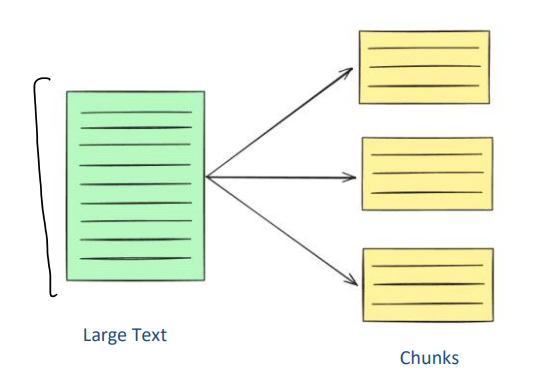

---

### Why Text Splitting is Important

1. **Overcoming Model Limitations Model Context Length**   
   Many embedding models and LLMs have maximum input size limits.  
   Splitting allows processing of documents that exceed these limits.

3. **Improves Downstream Tasks**  
   Text splitting enhances performance in tasks like:
   - Retrieval (RAG)  
   - Embeddings  
   - Question answering  
   - Summarization
   - Semantic Searching 

4. **Optimizing Computational Resources**  
   Smaller chunks:
   - Use less memory  
   - Enable better parallel processing  
   - Improve efficiency

## Types of Text Splitters in LangChain

- **CharacterTextSplitter** – Splits text based on character count.
- **RecursiveCharacterTextSplitter** – Splits text intelligently using multiple separators (recommended).
- **TokenTextSplitter** – Splits text based on token count (useful for LLM limits).
- **MarkdownHeaderTextSplitter** – Splits Markdown text based on headers.
- **HTMLHeaderTextSplitter** – Splits HTML content based on HTML tags.
``


In [4]:
from langchain_text_splitters import CharacterTextSplitter

text = """
Cricket is a globally popular sport that originated in England and has since become a major pastime in countries like India, Australia, Pakistan, and South Africa. It is played between two teams, each usually consisting of eleven players, and combines elements of strategy, skill, and endurance. The game revolves around batting and bowling, with the batting team trying to score runs while the bowling and fielding team attempts to restrict runs and dismiss the batsmen. Cricket is known for its variety of formats, from the fast-paced Twenty20 matches to the traditional five-day Test matches, each offering unique challenges and excitement. Beyond the physical game, cricket has a rich cultural and social impact, uniting fans across nations and inspiring passion, rivalry, and a deep sense of community.
"""

splitter = CharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,   # Retain Context between chunks(10 to 20 percent is good number)
    separator=''
)
result = splitter.split_text(text)

In [5]:
print(result)

['Cricket is a globally popular sport that originated in England and has since become a major pastime', 'in countries like India, Australia, Pakistan, and South Africa. It is played between two teams, eac', 'h usually consisting of eleven players, and combines elements of strategy, skill, and endurance. The', 'game revolves around batting and bowling, with the batting team trying to score runs while the bowl', 'ing and fielding team attempts to restrict runs and dismiss the batsmen. Cricket is known for its va', 'riety of formats, from the fast-paced Twenty20 matches to the traditional five-day Test matches, eac', 'h offering unique challenges and excitement. Beyond the physical game, cricket has a rich cultural a', 'nd social impact, uniting fans across nations and inspiring passion, rivalry, and a deep sense of co', 'mmunity.']


In [6]:
from langchain_community.document_loaders import PyPDFLoader

# Load PDF file
loader = PyPDFLoader("dl-curriculum.pdf")

# Each page becomes a separate Document
docs = loader.load()

result = splitter.split_documents(docs)

In [9]:
print(result[0].page_content)

CampusXDeepLearningCurriculum
A.ArtificialNeuralNetworkandhowtoimprovethem
1.BiologicalInspiration
●


## Recursive Character Text Splitting

Recursive Character Text Splitter intelligently splits text into chunks using multiple separators (like paragraphs, sentences, or spaces) while preserving context. It supports chunk size limits and overlap, making it ideal for LLMs and document processing.
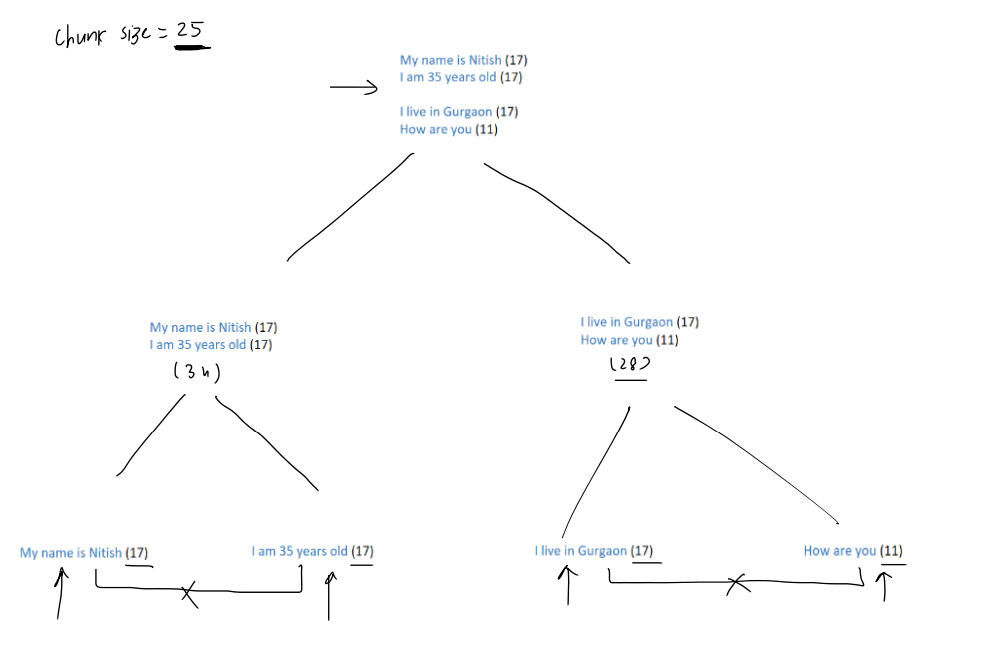
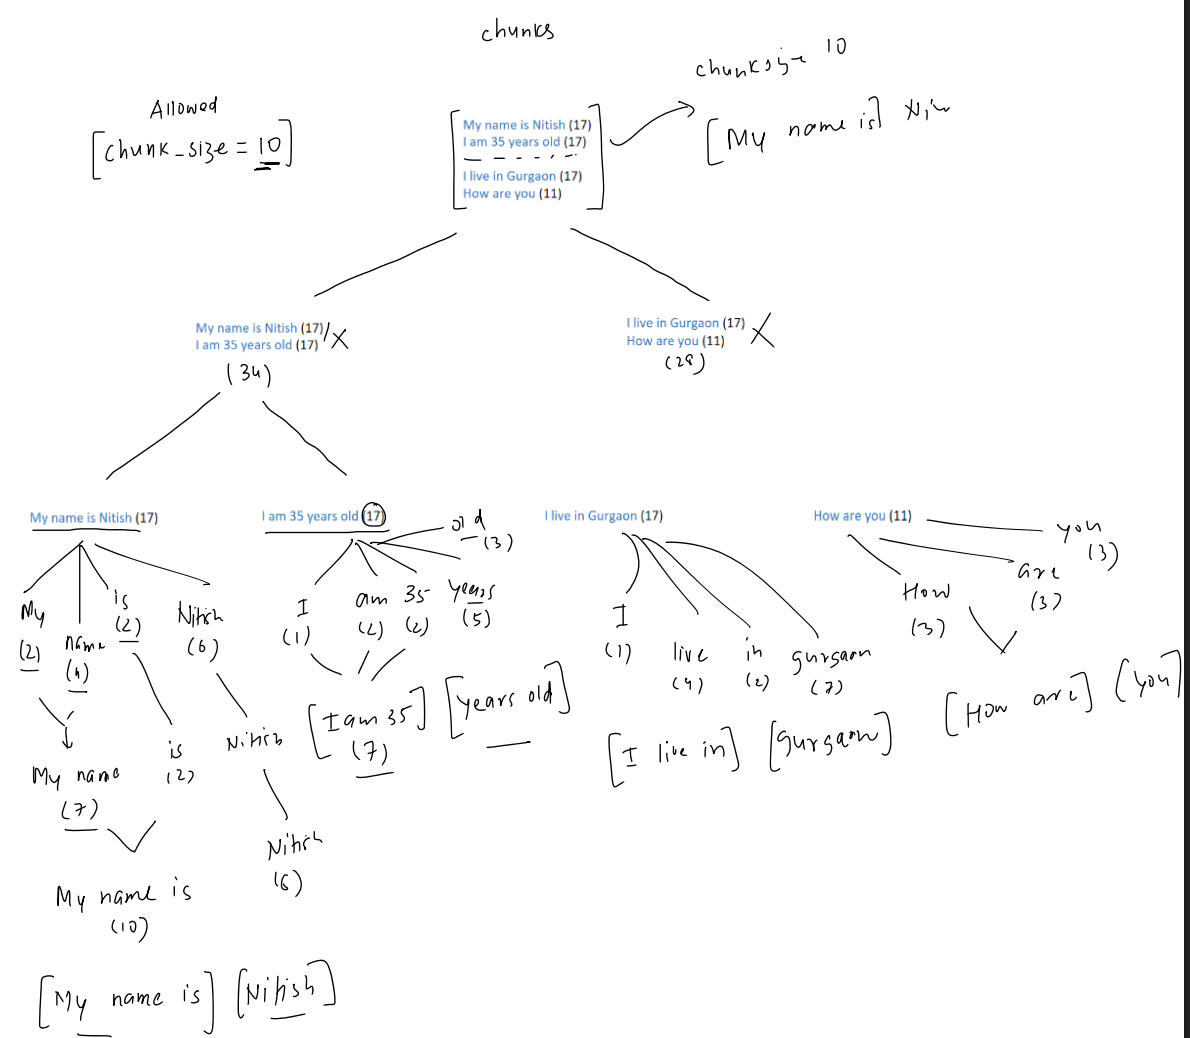


In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [12]:
text = """Cricket is a sport that originated in England. It is played by two teams of eleven players each.
The game involves batting, bowling, and fielding, with the objective to score runs and dismiss opponents.
Different formats like Test, ODI, and T20 offer varied strategies and excitement."""

splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20,
    separators=["\n\n", "\n", ".", " "]
)

chunks = splitter.split_text(text)

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}:\n{chunk}\n")

Chunk 1:
Cricket is a sport that originated in England. It is played by two teams of eleven players each.

Chunk 2:
The game involves batting, bowling, and fielding, with the objective to score runs and dismiss

Chunk 3:
runs and dismiss opponents

Chunk 4:
.

Chunk 5:
Different formats like Test, ODI, and T20 offer varied strategies and excitement.



## Document Structured Based
We want to split markdown or python file we use different splitters
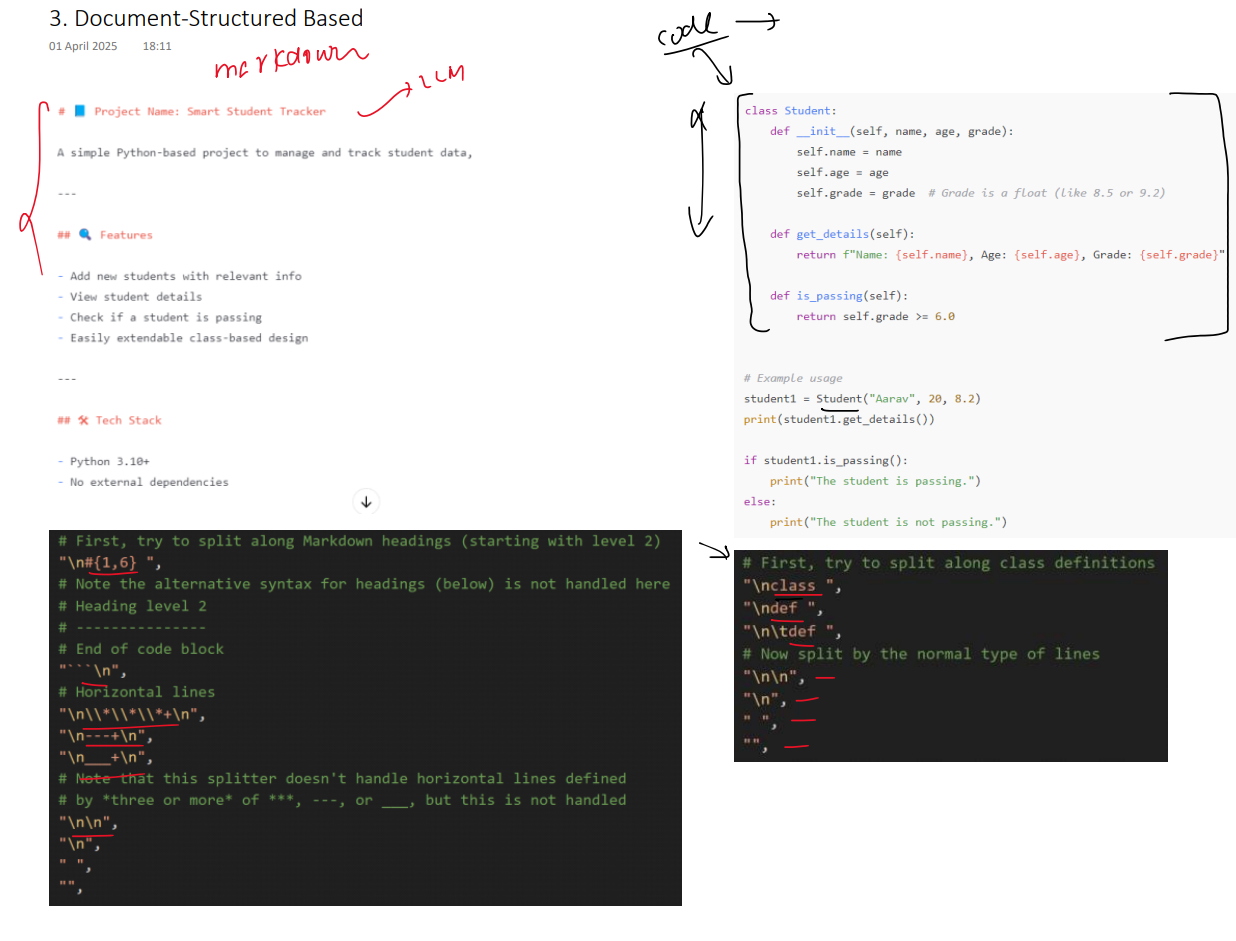

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language

In [14]:
text = """
class BankAccount:
    def __init__(self, owner, balance=0):
        self.owner = owner
        self.balance = balance

    def deposit(self, amount):
        self.balance += amount
        print(f"{amount} deposited. New balance: {self.balance}")

    def withdraw(self, amount):
        if amount > self.balance:
            print("Insufficient balance!")
        else:
            self.balance -= amount
            print(f"{amount} withdrawn. New balance: {self.balance}")

    def show_balance(self):
        print(f"{self.owner}'s balance: {self.balance}")

# Example usage
account = BankAccount("Alice", 500)
account.show_balance()
account.deposit(200)
account.withdraw(100
"""

In [18]:
splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON,
    chunk_size=250,
    chunk_overlap=20
)
chunks = splitter.split_text(text)

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}:\n{chunk}\n")

Chunk 1:
class BankAccount:
    def __init__(self, owner, balance=0):
        self.owner = owner
        self.balance = balance

    def deposit(self, amount):
        self.balance += amount
        print(f"{amount} deposited. New balance: {self.balance}")

Chunk 2:
def withdraw(self, amount):
        if amount > self.balance:
            print("Insufficient balance!")
        else:
            self.balance -= amount
            print(f"{amount} withdrawn. New balance: {self.balance}")

Chunk 3:
def show_balance(self):
        print(f"{self.owner}'s balance: {self.balance}")

# Example usage
account = BankAccount("Alice", 500)
account.show_balance()
account.deposit(200)
account.withdraw(100



## Semantic Meaning Based Splitters

Split text based on meaning rather than size, keeping context intact. Useful for LLMs, embeddings, and knowledge base creation.


In [19]:
text = """Cricket is a globally popular sport that originated in England, played by two teams of eleven players each. It combines strategy, skill, and endurance, with formats ranging from fast-paced T20 matches to traditional five-day Test matches. Apart from sports, renewable energy is rapidly gaining attention worldwide. Solar and wind power are being adopted to reduce carbon emissions and combat climate change, with many countries investing heavily in sustainable technologies.

Paragraph 2:
Artificial intelligence (AI) is transforming industries by automating tasks, analyzing large datasets, and enabling smarter decision-making. From healthcare and finance to education and transportation, AI applications are improving efficiency and creating new opportunities for innovation."""

In [23]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings
from dotenv import load_dotenv

load_dotenv()

True

In [29]:
text_splitter = SemanticChunker(
    OpenAIEmbeddings(), breakpoint_threshold_type="standard_deviation",
    breakpoint_threshold_amount=0.5
)
result = text_splitter.create_documents([text])

In [30]:
print(result)

[Document(metadata={}, page_content='Cricket is a globally popular sport that originated in England, played by two teams of eleven players each. It combines strategy, skill, and endurance, with formats ranging from fast-paced T20 matches to traditional five-day Test matches.'), Document(metadata={}, page_content='Apart from sports, renewable energy is rapidly gaining attention worldwide.'), Document(metadata={}, page_content='Solar and wind power are being adopted to reduce carbon emissions and combat climate change, with many countries investing heavily in sustainable technologies. Paragraph 2:\nArtificial intelligence (AI) is transforming industries by automating tasks, analyzing large datasets, and enabling smarter decision-making.'), Document(metadata={}, page_content='From healthcare and finance to education and transportation, AI applications are improving efficiency and creating new opportunities for innovation.')]
